In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense

In [ ]:
# Load your dataset
dataset = pd.read_csv("/content/Grocery_Inventory new v1.csv")
df = pd.DataFrame(dataset)

In [ ]:
df.head()

,Product_Name,Catagory,Supplier_Name,Warehouse_Location,Status,Product_ID,Supplier_ID,Date_Received,Last_Order_Date,Expiration_Date,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Sales_Volume,Inventory_Turnover_Rate,percentage
0,Bell Pepper,Fruits & Vegetables,Eimbee,20 Pennsylvania Parkway,Discontinued,29-017-6255,43-348-2450,3/1/2024,1/6/2025,1/31/2025,46,64,17,$4.60,96,55,1.96%
1,Vegetable Oil,Oils & Fats,Digitube,03643 Oakridge Lane,Backordered,79-569-8856,04-854-7165,4/1/2024,5/19/2024,6/11/2024,51,87,86,$2.00,24,83,0.91%
2,Parmesan Cheese,Dairy,BlogXS,73 Graedel Street,Discontinued,28-146-2641,82-995-0739,4/1/2024,12/21/2024,4/8/2024,38,67,66,$12.00,35,24,1.36%
3,Carrot,Fruits & Vegetables,Avaveo,44801 Myrtle Center,Discontinued,11-581-9869,22-867-3079,5/1/2024,12/12/2024,9/26/2024,51,60,98,$1.50,44,95,1.36%
4,Garlic,Fruits & Vegetables,Katz,6195 Monterey Center,Discontinued,13-202-4809,24-281-7685,5/1/2024,7/28/2024,5/20/2024,27,22,89,$7.00,91,77,2.17%


In [ ]:
# Unique categories
print("Unique Categories:", df['Catagory'].nunique())
print("Category Types:\n", df['Catagory'].unique())

# Count of products per category
category_counts = df['Catagory'].value_counts()
print(category_counts)

Unique Categories: 7
Category Types:
 ['Fruits & Vegetables' 'Oils & Fats' 'Dairy' 'Grains & Pulses' 'Seafood'
 'Bakery' 'Beverages' nan]
Catagory
Fruits & Vegetables    331
Dairy                  180
Grains & Pulses        162
Seafood                 90
Oils & Fats             77
Beverages               75
Bakery                  74
Name: count, dtype: int64


In [ ]:
 #Total unique products
print("Unique Products:", df['Product_Name'].nunique())
print("Sample Product Types:\n", df['Product_Name'].unique()[:122])  # Show top 10

Unique Products: 121
Sample Product Types:
 ['Bell Pepper' 'Vegetable Oil' 'Parmesan Cheese' 'Carrot' 'Garlic' 'Lemon'
 'Coconut Sugar' 'Anchovies' 'Cheese' 'Yogurt' 'Cheddar Cheese'
 'Avocado Oil' 'Orange' 'Digestive Biscuit' 'Cauliflower' 'Pear'
 'Egg (Turkey)' 'Ricotta Cheese' 'Eggplant' 'Whole Wheat Flour'
 'Arabica Coffee' 'Sweet Potato' 'Mango' 'Kale' 'Jasmine Rice'
 'Sourdough Bread' 'Green Coffee' 'Tilapia' 'Arborio Rice' 'Bread Flour'
 'Cucumber' 'Milk' 'Lime' 'Rice Flour' 'Sour Cream' 'Whole Wheat Bread'
 'Robusta Coffee' 'Chocolate Biscuit' 'Palm Oil' 'Sesame Oil' 'Lettuce'
 'Feta Cheese' 'Apricot' 'Peanut Oil' 'Olive Oil' 'Egg (Duck)' 'Pineapple'
 'Trout' 'Onion' 'Cream' 'Sardines' 'Plum' 'Sushi Rice' 'Black Rice'
 'Wild Rice' 'Pomegranate' 'Cabbage' 'All-Purpose Flour' 'Whipped Cream'
 'Grapes' 'Sunflower Oil' 'Short Grain Rice' 'Tuna' 'Banana' 'Coconut'
 'Almond Flour' 'Greek Yogurt' 'Peach' 'Asparagus' 'Mushrooms' 'Black Tea'
 'White Tea' 'White Rice' 'Long Grain Rice' '

In [ ]:
# Unique status types
print("Status Types:", df['Status'].unique())


# Count of products per category
Status_counts = df['Status'].value_counts()
print(Status_counts)

Status Types: ['Discontinued' 'Backordered' 'Active']
Status
Discontinued    333
Active          332
Backordered     325
Name: count, dtype: int64


In [ ]:
# Rename using mapping dictionary
df['Status'] = df['Status'].replace({
    'Active': 'In Stock',
    'Discontinued': 'Out of Stock',
    'Backordered': 'Awaiting Restock'
})

# View unique values after renaming
print(df['Status'].unique())

# Optional: View counts
print(df['Status'].value_counts())

['Out of Stock' 'Awaiting Restock' 'In Stock']
Status
Out of Stock        333
In Stock            332
Awaiting Restock    325
Name: count, dtype: int64


In [ ]:
df['Status'] = df['Status'].replace('Out od Stock', 'Out of Stock')


In [ ]:
print(df['Status'].value_counts())

Status
Out of Stock        333
In Stock            332
Awaiting Restock    325
Name: count, dtype: int64


In [ ]:
product_counts = df['Product_Name'].value_counts()
print(product_counts)


Product_Name
Bread Flour          19
Arabica Coffee       16
Cauliflower          15
Pomegranate          15
Grapes               14
                     ..
Banana                4
Cherry                4
Cottage Cheese        4
All-Purpose Flour     3
Vanilla Biscuit       3
Name: count, Length: 121, dtype: int64


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(sales_ts[['Sales_Volume']])

def create_sequences(data, time_steps=3):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

time_steps = 3
X, y = create_sequences(scaled_data, time_steps)

# Split into train/test
split = int(len(X) * 0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Product_ID_Encoded'] = le.fit_transform(df['Product_Name'])


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Sales_Volume_Scaled'] = scaler.fit_transform(df[['Sales_Volume']])


In [ ]:
# Config
time_steps = 3

X, y = [], []

# Loop through each product
for product_id in df['Product_ID_Encoded'].unique():
    product_df = df[df['Product_ID_Encoded'] == product_id]
    product_sales = product_df['Sales_Volume_Scaled'].values

    for i in range(len(product_sales) - time_steps):
        # Features = sales sequence + product ID
        seq = product_sales[i:i+time_steps]
        X.append(np.column_stack([seq, [product_id]*time_steps]))
        y.append(product_sales[i+time_steps])


In [ ]:
X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)  # (samples, time_steps, 2)


X shape: (627, 3, 2)


Each time step will now have 2 features:

Scaled Sales

Encoded Product ID

In [ ]:
model = Sequential()
model.add(LSTM(64, return_sequences=False, input_shape=(X.shape[1], X.shape[2])))
#model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.2502 - val_loss: 0.1272
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1116 - val_loss: 0.0840
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0881 - val_loss: 0.0824
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0831 - val_loss: 0.0820
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0831 - val_loss: 0.0809
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0872 - val_loss: 0.0813
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0833 - val_loss: 0.0807
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0833 - val_loss: 0.0814
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0832 - val_loss: 0.0815
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0841 - val_loss: 0.0801
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0886 - val_loss: 0.0808
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0801 - val_loss: 0.0812

In [ ]:
product_name = "Bread Flour"
product_id = le.transform([product_name])[0]
last_sales = df[df['Product_ID_Encoded'] == product_id]['Sales_Volume_Scaled'].values[-time_steps:]

# Prepare input
X_pred = np.column_stack([last_sales, [product_id]*time_steps]).reshape(1, time_steps, 2)

y_pred = model.predict(X_pred)
y_pred_actual = scaler.inverse_transform(y_pred)
print(f"Predicted sales for {product_name}: {y_pred_actual[0][0]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Predicted sales for Bread Flour: 54.67


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


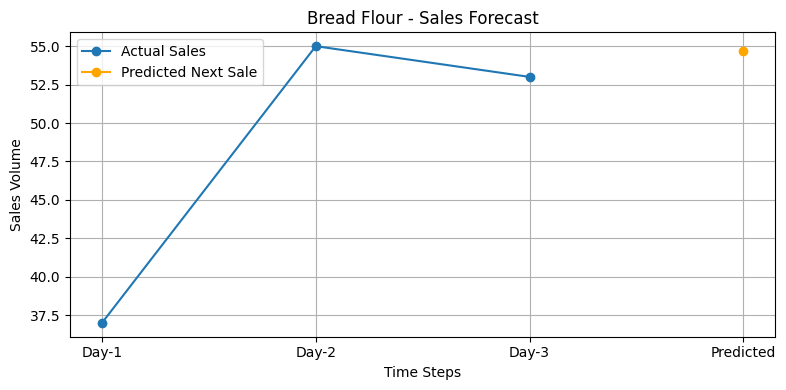

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

product_name = "Bread Flour"
product_id = le.transform([product_name])[0]
time_steps = 3  # make sure this matches your training setup

# Get last sales values
product_df = df[df['Product_ID_Encoded'] == product_id]
last_sales_scaled = product_df['Sales_Volume_Scaled'].values[-time_steps:]
last_sales_actual = product_df['Sales_Volume'].values[-time_steps:]

# Prepare input
X_pred = np.column_stack([last_sales_scaled, [product_id]*time_steps]).reshape(1, time_steps, 2)

# Predict
y_pred_scaled = model.predict(X_pred)
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, time_steps + 1), last_sales_actual, marker='o', label='Actual Sales')
plt.plot(time_steps + 1, y_pred_actual[0][0], marker='o', color='orange', label='Predicted Next Sale')

plt.title(f'{product_name} - Sales Forecast')
plt.xlabel('Time Steps')
plt.ylabel('Sales Volume')
plt.xticks(ticks=range(1, time_steps + 2), labels=[f'Day-{i}' for i in range(1, time_steps + 1)] + ['Predicted'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


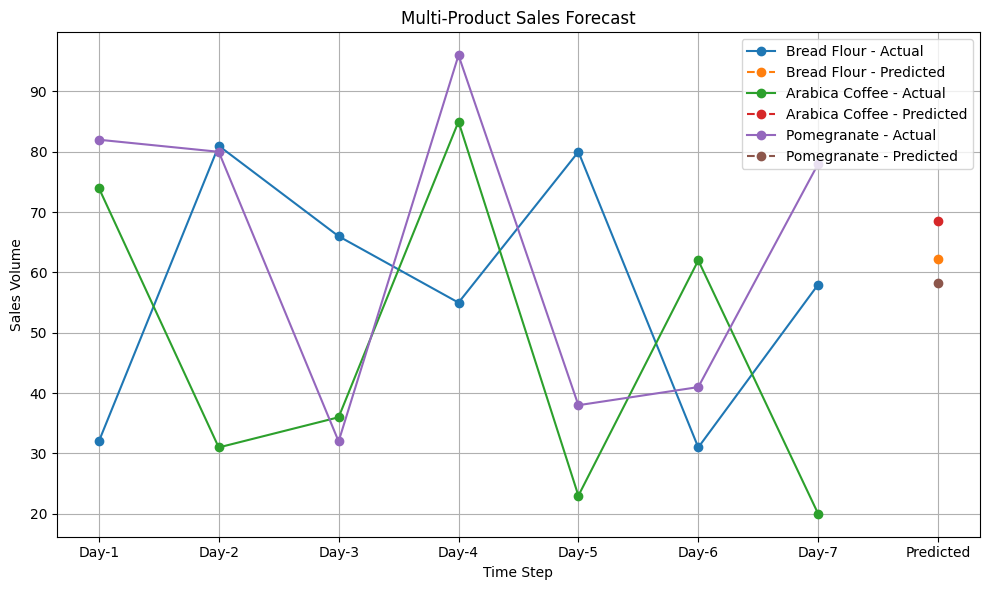

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# List of products to predict
product_names = ["Bread Flour", "Arabica Coffee", "Pomegranate"]
time_steps = 7

plt.figure(figsize=(10, 6))

for product_name in product_names:
    # Get encoded product ID
    product_id = le.transform([product_name])[0]

    # Filter and sort the product data
    product_df = df[df['Product_ID_Encoded'] == product_id].sort_values('Last_Order_Date')

    # Get last sales data
    last_sales_scaled = product_df['Sales_Volume_Scaled'].values[-time_steps:]
    last_sales_actual = product_df['Sales_Volume'].values[-time_steps:]

    # Prepare model input
    X_pred = np.column_stack([last_sales_scaled, [product_id]*time_steps]).reshape(1, time_steps, 2)

    # Predict
    y_pred_scaled = model.predict(X_pred)
    y_pred_actual = scaler.inverse_transform(y_pred_scaled)[0][0]

    # Plot last actual sales
    plt.plot(range(1, time_steps + 1), last_sales_actual, marker='o', label=f'{product_name} - Actual')

    # Plot prediction
    plt.plot(time_steps + 1, y_pred_actual, marker='o', linestyle='--', label=f'{product_name} - Predicted')

# Plot settings
plt.title("Multi-Product Sales Forecast")
plt.xlabel("Time Step")
plt.ylabel("Sales Volume")
plt.xticks(ticks=range(1, time_steps + 2), labels=[f'Day-{i}' for i in range(1, time_steps + 1)] + ['Predicted'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Save the model to a file (HDF5 format)
model.save('sales_forecasting_model.h5')
